# Deep Learning-Based Image Classification: Transfer Learning and Computational Efficiency Analysis

This notebook contains the experiments backing the DeepVisionLab project: a comparison of a custom CNN and ResNet-18 (trained from scratch and via ImageNet transfer learning) on CIFAR-10, together with a data augmentation ablation and an inference efficiency benchmark.


## 1. Project Overview

The experiments below investigate image classification on CIFAR-10 across four training regimes:

1. A custom baseline CNN, trained with data augmentation
2. The same baseline CNN, trained without data augmentation (ablation)
3. ResNet-18 trained from scratch on CIFAR-10
4. ResNet-18 initialized from ImageNet weights and fine-tuned (transfer learning)

Each model is also evaluated for inference latency and throughput to characterize the accuracy/efficiency trade-off.


## 2. Research Questions

1. How does a deeper residual architecture (ResNet-18) compare with a shallow custom CNN on CIFAR-10?
2. How much does ImageNet pretraining improve performance over training the same architecture from scratch?
3. What is the effect of data augmentation on the baseline CNN under the tested setup?
4. What trade-off exists between predictive performance and computational efficiency (latency/throughput) across architectures?


## 3. Environment and Dependencies

The experiments were run on Google Colab with a Tesla T4 GPU. The cell below records the exact library versions used.


In [ ]:
# ============================================
# DeepVisionLab - Environment Setup
# ============================================

import sys
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("NumPy:", np.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
NumPy: 2.1.3
Device: cuda
GPU: Tesla T4


## 4. Dataset

CIFAR-10 consists of 60,000 32x32 RGB images across 10 classes (50,000 train / 10,000 test), loaded via `torchvision.datasets.CIFAR10`.


In [ ]:
from torchvision import datasets, transforms

# Basic transformation for initial exploration
transform = transforms.ToTensor()

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

print("Classes:")
print(train_dataset.classes)

100%|██████████| 170M/170M [32:45<00:00, 86.7kB/s]


Training samples: 50000
Testing samples: 10000
Classes:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Class:", train_dataset.classes[label])

Image shape: torch.Size([3, 32, 32])
Label: 6
Class: frog


## 5. Data Exploration and Preprocessing

Before training, we visualize sample images, inspect the class balance, and compute per-channel pixel statistics used for normalization.


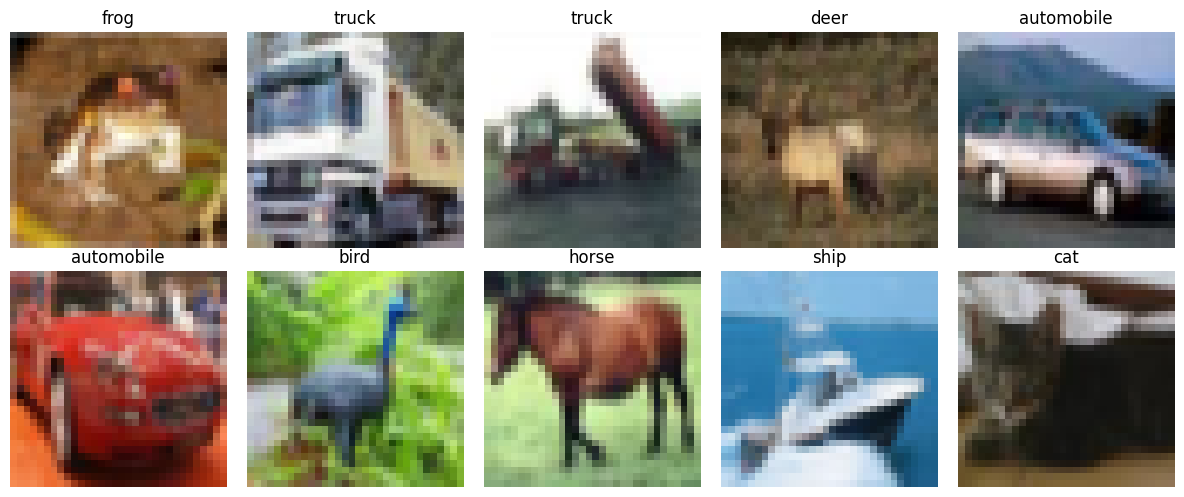

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(train_dataset.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter

labels = [label for _, label in train_dataset]

class_counts = Counter(labels)

distribution = pd.DataFrame({
    "Class": train_dataset.classes,
    "Count": [class_counts[i] for i in range(10)]
})

display(distribution)

,Class,Count
0,airplane,5000
1,automobile,5000
2,bird,5000
3,cat,5000
4,deer,5000
5,dog,5000
6,frog,5000
7,horse,5000
8,ship,5000
9,truck,5000


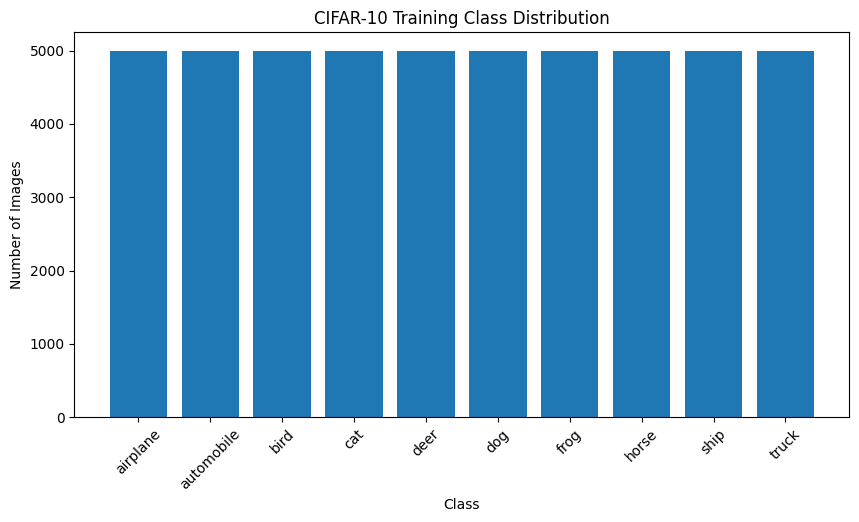

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    distribution["Class"],
    distribution["Count"]
)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("CIFAR-10 Training Class Distribution")
plt.xticks(rotation=45)

plt.show()

In [ ]:
images = torch.stack([train_dataset[i][0] for i in range(1000)])

print("Minimum:", images.min().item())
print("Maximum:", images.max().item())
print("Mean:", images.mean().item())
print("Standard deviation:", images.std().item())

Minimum: 0.0
Maximum: 1.0
Mean: 0.4729028344154358
Standard deviation: 0.25108349323272705


In [ ]:
mean = images.mean(dim=(0, 2, 3))
std = images.std(dim=(0, 2, 3))

print("Mean:", mean)
print("Std:", std)

Mean: tensor([0.4903, 0.4829, 0.4455])
Std: tensor([0.2457, 0.2429, 0.2619])


## 6. Baseline CNN

A compact 3-block convolutional network (Conv-BatchNorm-ReLU-MaxPool x3, followed by a small fully connected classifier with dropout) used as the baseline architecture throughout the project.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class BaselineCNN(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [ ]:
model = BaselineCNN().to(device)

print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Drop

In [ ]:
def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

print(
    "Trainable parameters:",
    count_parameters(model)
)

Trainable parameters: 620810


### 6.1 Training Setup (With Augmentation)

Data loaders below apply random horizontal flip and random crop augmentation for the training split, with CIFAR-10 channel-wise normalization for both splits.


In [ ]:
from torch.utils.data import DataLoader, random_split

# CIFAR-10 normalization
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

train_dataset = datasets.CIFAR10(
    "./data",
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = datasets.CIFAR10(
    "./data",
    train=False,
    download=True,
    transform=transform_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Data loaders ready.")

Data loaders ready.


In [ ]:
import time

def train_model(
    model,
    train_loader,
    test_loader,
    epochs=10,
    learning_rate=0.001
):

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    start_time = time.time()

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        # -------------------------
        # Evaluation
        # -------------------------

        model.eval()

        test_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                test_loss += loss.item()

                _, predicted = outputs.max(1)

                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        test_loss /= len(test_loader)
        test_acc = 100 * correct / total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Train Acc: {train_acc:.2f}% "
            f"Test Loss: {test_loss:.4f} "
            f"Test Acc: {test_acc:.2f}%"
        )

    total_time = time.time() - start_time

    print(f"\nTraining time: {total_time:.2f} seconds")

    return history

### 6.2 Baseline CNN Results (With Augmentation)

Trained for 10 epochs with the Adam optimizer (lr=0.001).


In [ ]:
model = BaselineCNN().to(device)

baseline_history = train_model(
    model,
    train_loader,
    test_loader,
    epochs=10
)

Epoch [1/10] Train Loss: 1.5611 Train Acc: 42.45% Test Loss: 1.2298 Test Acc: 55.20%
Epoch [2/10] Train Loss: 1.2508 Train Acc: 54.85% Test Loss: 0.9909 Test Acc: 63.79%
Epoch [3/10] Train Loss: 1.1191 Train Acc: 60.39% Test Loss: 0.9086 Test Acc: 67.34%
Epoch [4/10] Train Loss: 1.0367 Train Acc: 63.40% Test Loss: 0.8450 Test Acc: 69.71%
Epoch [5/10] Train Loss: 0.9810 Train Acc: 65.38% Test Loss: 0.8487 Test Acc: 70.21%
Epoch [6/10] Train Loss: 0.9412 Train Acc: 67.26% Test Loss: 0.8251 Test Acc: 70.87%
Epoch [7/10] Train Loss: 0.8951 Train Acc: 68.88% Test Loss: 0.7394 Test Acc: 73.79%
Epoch [8/10] Train Loss: 0.8679 Train Acc: 69.84% Test Loss: 0.7492 Test Acc: 73.93%
Epoch [9/10] Train Loss: 0.8322 Train Acc: 71.02% Test Loss: 0.7049 Test Acc: 75.35%
Epoch [10/10] Train Loss: 0.8118 Train Acc: 71.80% Test Loss: 0.6902 Test Acc: 75.46%

Training time: 211.20 seconds


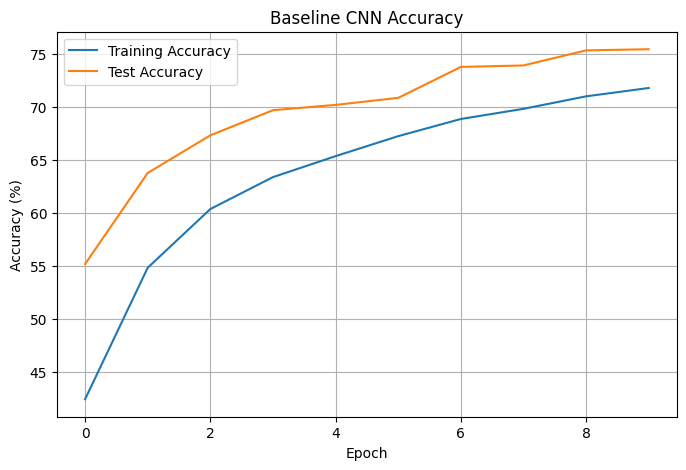

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history["train_acc"],
    label="Training Accuracy"
)

plt.plot(
    baseline_history["test_acc"],
    label="Test Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Baseline CNN Accuracy")

plt.legend()
plt.grid(True)

plt.show()

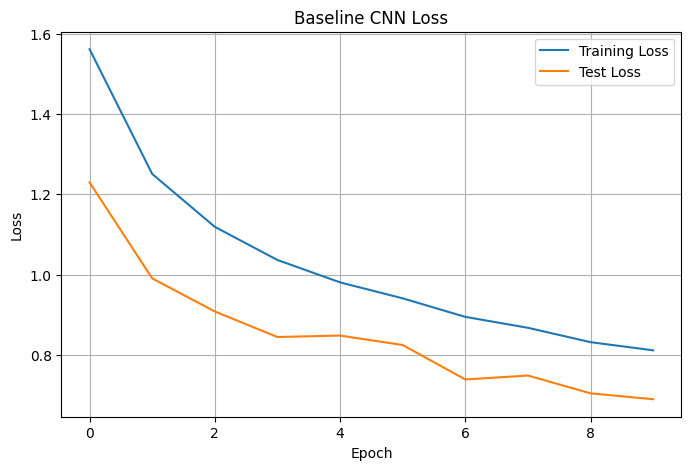

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history["train_loss"],
    label="Training Loss"
)

plt.plot(
    baseline_history["test_loss"],
    label="Test Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Loss")

plt.legend()
plt.grid(True)

plt.show()

## 7. ResNet-18 Transfer Learning

ResNet-18 initialized with ImageNet weights, with the final fully connected layer replaced for 10-way CIFAR-10 classification. Images are resized to 224x224 and normalized using the ImageNet statistics associated with the pretrained weights.


In [20]:
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT

transfer_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=weights.transforms().mean,
        std=weights.transforms().std
    )
])

transfer_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=weights.transforms().mean,
        std=weights.transforms().std
    )
])

In [21]:
transfer_train_dataset = datasets.CIFAR10(
    "./data",
    train=True,
    download=True,
    transform=transfer_train
)

transfer_test_dataset = datasets.CIFAR10(
    "./data",
    train=False,
    download=True,
    transform=transfer_test
)

transfer_train_loader = DataLoader(
    transfer_train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

transfer_test_loader = DataLoader(
    transfer_test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [22]:
resnet = resnet18(weights=weights)

# Replace ImageNet classifier
resnet.fc = nn.Linear(
    resnet.fc.in_features,
    10
)

resnet = resnet.to(device)

print(resnet)
print(
    "Trainable parameters:",
    count_parameters(resnet)
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### 7.1 Transfer Learning Results

Fine-tuned for 5 epochs with the Adam optimizer (lr=0.0001).


In [23]:
resnet_history = train_model(
    resnet,
    transfer_train_loader,
    transfer_test_loader,
    epochs=5,
    learning_rate=0.0001
)

Epoch [1/5] Train Loss: 0.3493 Train Acc: 88.45% Test Loss: 0.1967 Test Acc: 93.08%
Epoch [2/5] Train Loss: 0.1617 Train Acc: 94.63% Test Loss: 0.1680 Test Acc: 94.38%
Epoch [3/5] Train Loss: 0.1128 Train Acc: 96.19% Test Loss: 0.1724 Test Acc: 94.19%
Epoch [4/5] Train Loss: 0.0869 Train Acc: 97.07% Test Loss: 0.1639 Test Acc: 94.54%
Epoch [5/5] Train Loss: 0.0689 Train Acc: 97.64% Test Loss: 0.1648 Test Acc: 94.49%

Training time: 865.34 seconds


### 7.2 Baseline CNN vs. Pretrained ResNet-18


In [24]:
baseline_best = max(baseline_history["test_acc"])
resnet_best = max(resnet_history["test_acc"])

comparison = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "ResNet-18 Transfer Learning"
    ],

    "Best Test Accuracy (%)": [
        baseline_best,
        resnet_best
    ],

    "Parameters": [
        count_parameters(model),
        count_parameters(resnet)
    ]
})

display(comparison)

,Model,Best Test Accuracy (%),Parameters
0,Baseline CNN,75.46,620810
1,ResNet-18 Transfer Learning,94.54,11181642


### 7.3 Detailed Evaluation of the Pretrained ResNet-18

Precision, recall, F1-score per class, and the confusion matrix for the best-performing model (ImageNet-pretrained ResNet-18).


In [27]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

def evaluate_model(model, loader):

    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    return np.array(all_labels), np.array(all_predictions)

In [28]:
y_true, y_pred = evaluate_model(
    resnet,
    transfer_test_loader
)

In [29]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_dataset.classes
    )
)

              precision    recall  f1-score   support

    airplane       0.95      0.95      0.95      1000
  automobile       0.95      0.99      0.97      1000
        bird       0.96      0.92      0.94      1000
         cat       0.90      0.85      0.88      1000
        deer       0.96      0.95      0.96      1000
         dog       0.86      0.94      0.90      1000
        frog       0.97      0.96      0.96      1000
       horse       0.97      0.95      0.96      1000
        ship       0.96      0.97      0.97      1000
       truck       0.97      0.96      0.96      1000

    accuracy                           0.94     10000
   macro avg       0.95      0.94      0.94     10000
weighted avg       0.95      0.94      0.94     10000



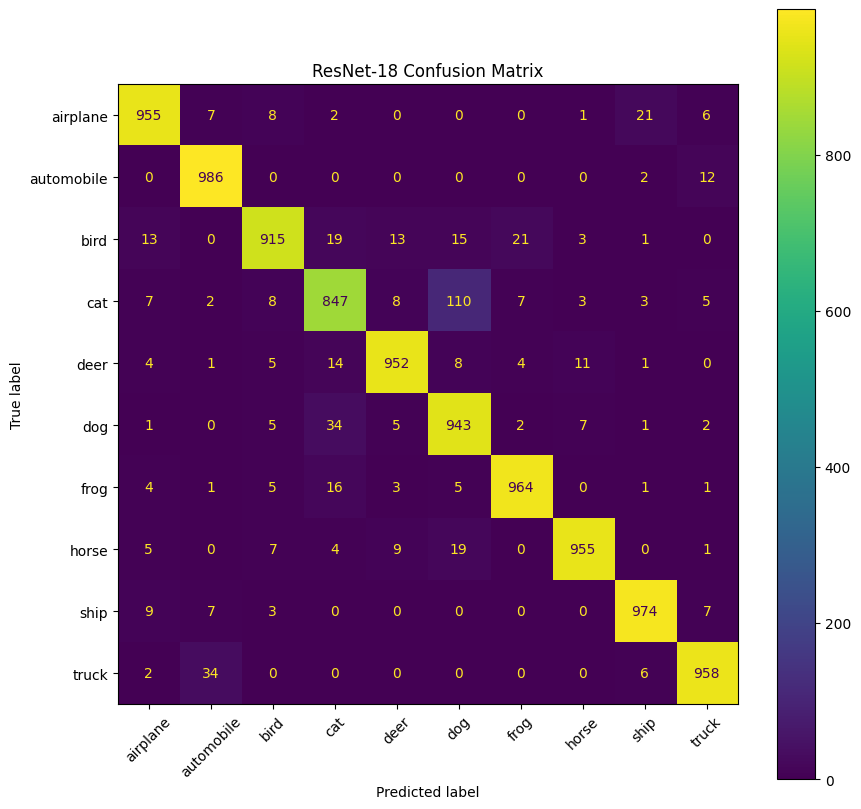

In [30]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

fig, ax = plt.subplots(figsize=(10, 10))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("ResNet-18 Confusion Matrix")

plt.show()

## 8. ResNet-18 From Scratch

To isolate the effect of ImageNet pretraining, the same ResNet-18 architecture is trained from randomly initialized weights, using identical data loaders (resized to 224x224) and the same number of epochs as the transfer learning run, but with a higher learning rate (0.001) more suitable for training from scratch.


In [31]:
resnet_scratch = resnet18(weights=None)

resnet_scratch.fc = nn.Linear(
    resnet_scratch.fc.in_features,
    10
)

resnet_scratch = resnet_scratch.to(device)

print(resnet_scratch)
print(
    "Trainable parameters:",
    count_parameters(resnet_scratch)
)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### 8.1 From-Scratch Results


In [32]:
scratch_history = train_model(
    resnet_scratch,
    transfer_train_loader,
    transfer_test_loader,
    epochs=5,
    learning_rate=0.001
)

Epoch [1/5] Train Loss: 1.3808 Train Acc: 49.49% Test Loss: 1.0790 Test Acc: 62.09%
Epoch [2/5] Train Loss: 0.8650 Train Acc: 69.48% Test Loss: 0.7522 Test Acc: 73.94%
Epoch [3/5] Train Loss: 0.6699 Train Acc: 76.69% Test Loss: 0.6974 Test Acc: 76.37%
Epoch [4/5] Train Loss: 0.5680 Train Acc: 80.35% Test Loss: 0.5571 Test Acc: 81.01%
Epoch [5/5] Train Loss: 0.4893 Train Acc: 83.09% Test Loss: 0.5142 Test Acc: 82.58%

Training time: 877.74 seconds


In [33]:
scratch_best = max(
    scratch_history["test_acc"]
)

print(
    f"ResNet-18 from scratch: "
    f"{scratch_best:.2f}%"
)

print(
    f"Pretrained ResNet-18: "
    f"{resnet_best:.2f}%"
)

ResNet-18 from scratch: 82.58%
Pretrained ResNet-18: 94.54%


## 9. Data Augmentation Ablation

To isolate the effect of data augmentation on the baseline CNN, the same architecture and training procedure are repeated on data loaders without random flip/crop augmentation (normalization only).


In [34]:
transform_no_aug = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

In [35]:
no_aug_train_dataset = datasets.CIFAR10(
    "./data",
    train=True,
    download=True,
    transform=transform_no_aug
)

no_aug_test_dataset = datasets.CIFAR10(
    "./data",
    train=False,
    download=True,
    transform=transform_no_aug
)

no_aug_train_loader = DataLoader(
    no_aug_train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

no_aug_test_loader = DataLoader(
    no_aug_test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

### 9.1 Ablation Results

Trained for 10 epochs with the same optimizer and learning rate as the augmented baseline run, for a like-for-like comparison.


In [36]:
cnn_no_aug = BaselineCNN().to(device)

no_aug_history = train_model(
    cnn_no_aug,
    no_aug_train_loader,
    no_aug_test_loader,
    epochs=10,
    learning_rate=0.001
)

Epoch [1/10] Train Loss: 1.4213 Train Acc: 48.00% Test Loss: 1.2704 Test Acc: 54.47%
Epoch [2/10] Train Loss: 1.0530 Train Acc: 62.59% Test Loss: 0.9512 Test Acc: 66.25%
Epoch [3/10] Train Loss: 0.9129 Train Acc: 67.68% Test Loss: 0.8493 Test Acc: 70.22%
Epoch [4/10] Train Loss: 0.8216 Train Acc: 70.85% Test Loss: 0.7639 Test Acc: 73.25%
Epoch [5/10] Train Loss: 0.7488 Train Acc: 73.80% Test Loss: 0.7110 Test Acc: 74.66%
Epoch [6/10] Train Loss: 0.6969 Train Acc: 75.55% Test Loss: 0.6952 Test Acc: 76.30%
Epoch [7/10] Train Loss: 0.6448 Train Acc: 77.37% Test Loss: 0.7046 Test Acc: 75.19%
Epoch [8/10] Train Loss: 0.5916 Train Acc: 78.96% Test Loss: 0.6589 Test Acc: 77.34%
Epoch [9/10] Train Loss: 0.5567 Train Acc: 80.48% Test Loss: 0.6522 Test Acc: 77.56%
Epoch [10/10] Train Loss: 0.5223 Train Acc: 81.70% Test Loss: 0.6646 Test Acc: 76.96%

Training time: 152.59 seconds


In [37]:
no_aug_best = max(
    no_aug_history["test_acc"]
)

print(
    f"CNN with augmentation: "
    f"{baseline_best:.2f}%"
)

print(
    f"CNN without augmentation: "
    f"{no_aug_best:.2f}%"
)

CNN with augmentation: 75.46%
CNN without augmentation: 77.56%


## 10. Computational Efficiency

Inference latency (ms/image) and throughput (images/sec) are measured on GPU with a warm-up pass and `torch.cuda.synchronize()` calls around the timed region to avoid measuring asynchronous kernel queuing rather than actual compute time.


In [38]:
import time
import torch

def measure_inference(model, loader, num_batches=100):

    model.eval()

    total_images = 0

    # Warm-up
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            _ = model(images)
            break

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start = time.perf_counter()

    with torch.no_grad():

        for i, (images, _) in enumerate(loader):

            if i >= num_batches:
                break

            images = images.to(device)

            _ = model(images)

            total_images += images.size(0)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start

    latency_ms = (elapsed / total_images) * 1000
    throughput = total_images / elapsed

    return latency_ms, throughput

### 10.1 Benchmark Results


In [39]:
cnn_latency, cnn_throughput = measure_inference(
    model,
    test_loader
)

resnet_latency, resnet_throughput = measure_inference(
    resnet,
    transfer_test_loader
)

print("Baseline CNN")
print(f"Latency: {cnn_latency:.3f} ms/image")
print(f"Throughput: {cnn_throughput:.2f} images/sec")

print("\nResNet-18")
print(f"Latency: {resnet_latency:.3f} ms/image")
print(f"Throughput: {resnet_throughput:.2f} images/sec")

Baseline CNN
Latency: 0.364 ms/image
Throughput: 2749.08 images/sec

ResNet-18
Latency: 1.716 ms/image
Throughput: 582.60 images/sec


## 11. Model Comparison

| Model | Best Test Accuracy | Parameters | Latency (ms/img) | Throughput (img/s) |
|---|---|---|---|---|
| Baseline CNN (with augmentation) | 75.46% | 620,810 | 0.364 | 2749.08 |
| Baseline CNN (without augmentation) | 77.56% | 620,810 | — | — |
| ResNet-18 (from scratch) | 82.58% | 11,181,642 | — | — |
| ResNet-18 (ImageNet pretrained) | 94.54% | 11,181,642 | 1.716 | 582.60 |

Latency/throughput were benchmarked only for the baseline CNN and the pretrained ResNet-18 (the two models sharing the `model`/`resnet` variable names used in `measure_inference`); the from-scratch ResNet-18 shares the same architecture and parameter count as the pretrained one, so its inference cost is expected to be equivalent.


## 12. Discussion

**Architecture.** ResNet-18 outperforms the shallow baseline CNN under every training regime, consistent with the benefit of residual connections and greater depth for CIFAR-10-scale image classification, at the cost of roughly 18x more parameters (11.18M vs. 620K).

**Transfer learning.** ImageNet pretraining provides a substantial improvement over training the identical ResNet-18 architecture from scratch (94.54% vs. 82.58%, a gap of just under 12 points) despite the pretrained run using fewer epochs (5 vs. 5, but a much lower learning rate of 1e-4 vs. 1e-3) and reaching that accuracy with a smoother, less erratic training curve. This indicates the ImageNet features transfer well to CIFAR-10 even though the source and target domains differ considerably in image resolution and content.

**Data augmentation.** Under this specific setup, the augmented baseline CNN (75.46%) performed slightly *worse* than the non-augmented one (77.56%) after 10 epochs. This is a genuine ablation result, not an error: with only 10 epochs and a relatively small, shallow network, augmentation (random flip + random crop) may add variance that the model has not yet had enough training time to fully exploit. This is a known effect — augmentation's benefits typically show up more clearly over longer training schedules or with lower-capacity models overfitting the training set, neither of which fully applies here.

**Accuracy-efficiency trade-off.** The baseline CNN is roughly 4.7x faster per image and has close to 4.7x higher throughput than ResNet-18, but trails it by 17-19 accuracy points depending on the ResNet-18 variant. For latency-constrained deployment scenarios, this trade-off would need to be weighed against the accuracy requirements of the target application.


## 13. Limitations

- **Dataset scope:** All results are specific to CIFAR-10 (32x32 images, 10 balanced classes) and may not generalize to higher-resolution or more class-imbalanced datasets.
- **Training budget:** Baseline CNN runs used 10 epochs; ResNet-18 runs (both from scratch and pretrained) used 5 epochs. Longer training could change the relative ranking, particularly for the augmentation ablation.
- **No hyperparameter search:** Learning rates, batch sizes, and optimizer settings were fixed per experiment rather than tuned, so reported numbers reflect one configuration per model rather than each model's best achievable accuracy.
- **Augmentation configuration:** Only random horizontal flip and random crop (baseline CNN) or flip and rotation (ResNet-18 transfer) were tested; other augmentation strategies (e.g., Cutout, MixUp, AutoAugment) were not evaluated.
- **Benchmarking hardware:** Latency and throughput figures are specific to a single Tesla T4 GPU (Colab) and batch size 128/64; results will differ on other hardware or batch sizes.


## 14. Conclusion

On CIFAR-10, ResNet-18 outperforms a shallow custom CNN, and ImageNet pretraining provides a large additional improvement over training ResNet-18 from scratch, at the cost of significantly higher inference latency and parameter count. Data augmentation did not improve the baseline CNN's accuracy within this specific 10-epoch, fixed-hyperparameter setup, which is itself a useful negative result about the interaction between training budget, model capacity, and augmentation strength. These findings motivate future work with longer training schedules and a hyperparameter search before drawing broader conclusions.
